In [1]:
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray

In [2]:
img = rgb2gray(data.astronaut())

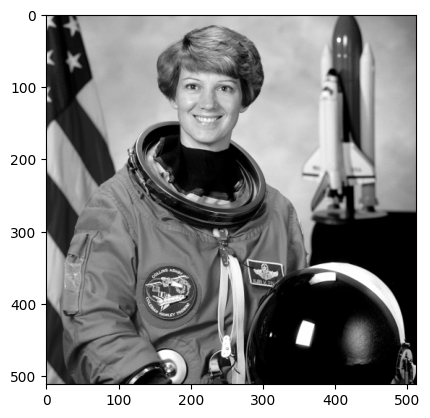

In [3]:
plt.imshow(img, cmap ='gray')
plt.show()

In [4]:
img.shape

(512, 512)

In [5]:
from skimage.feature import match_descriptors, SIFT

In [6]:
descriptor_extractor = SIFT()

descriptor_extractor.detect_and_extract(img)
keypoints = descriptor_extractor.keypoints
descriptors = descriptor_extractor.descriptors

In [7]:
print(keypoints.shape)
print(descriptors.shape)

(1234, 2)
(1234, 128)


In [8]:
# from skimage import plot_keypoints
# fig, ax = plt.subplots()
# plot_keypoints(img, keypoints,ax=ax)
# plt.show()

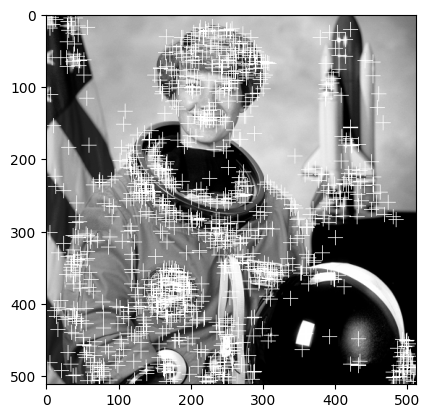

In [9]:
import cv2
def draw_keypoints(img, keypoints):
    img1 = img.copy()

    for kp in keypoints:
        x,y = kp[0],kp[1]

        x = int(round(x))
        y = int(round(y))



        cv2.drawMarker(img1, (y,x), color = (1,))


    return img1

img2 = draw_keypoints(img, keypoints)
# new_img = img+img2
plt.imshow(img2, cmap='gray')
plt.show()

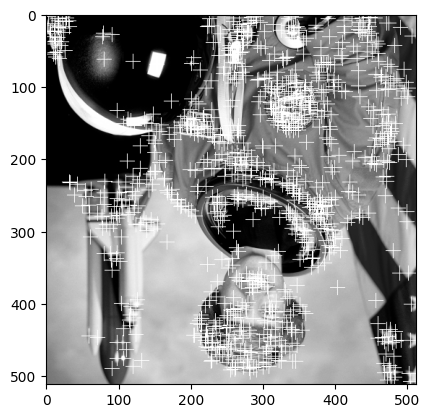

In [10]:
from skimage import transform
img_transform = transform.rotate(img,180)

descriptor_extractor.detect_and_extract(img_transform)
keypoints1 = descriptor_extractor.keypoints
descriptors1 = descriptor_extractor.descriptors

img2 = draw_keypoints(img_transform, keypoints1)
# new_img = img+img2
plt.imshow(img2, cmap='gray')
plt.show()

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def custom_plot_matches(ax, image1, image2, keypoints1, keypoints2, matches):
    # 拼接两张图
    new_image = np.concatenate((image1, image2), axis=1)
    ax.imshow(new_image, cmap='gray')

    cols1 = image1.shape[1]
    for m in matches:
        i, j = m
        y1, x1 = keypoints1[i]
        y2, x2 = keypoints2[j]
        ax.plot([x1, x2 + cols1], [y1, y2], 'r-', linewidth=0.5)
        ax.plot(x1, y1, 'bo', markersize=2)
        ax.plot(x2 + cols1, y2, 'bo', markersize=2)

    ax.axis('off')


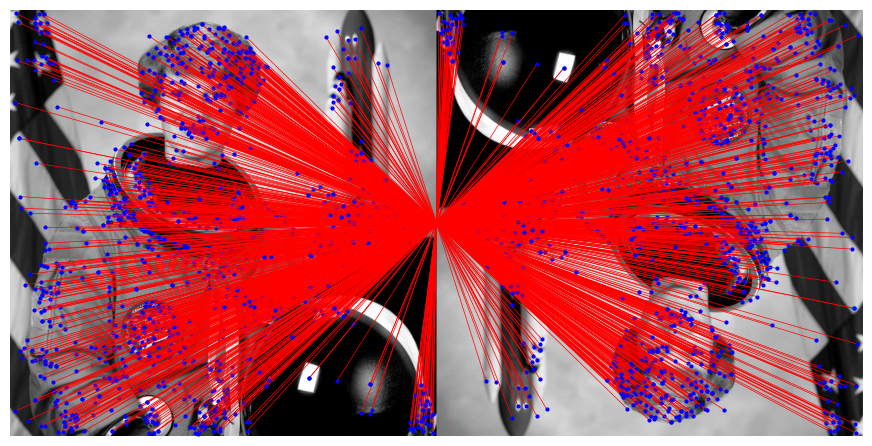

In [12]:
from skimage.feature import match_descriptors

matches = match_descriptors(descriptors, descriptors1, max_ratio = 0.6, cross_check=True)


fig, ax = plt.subplots(nrows=1,ncols=1,figsize = (11,8))


custom_plot_matches(ax, img, img_transform, keypoints, keypoints1, matches)


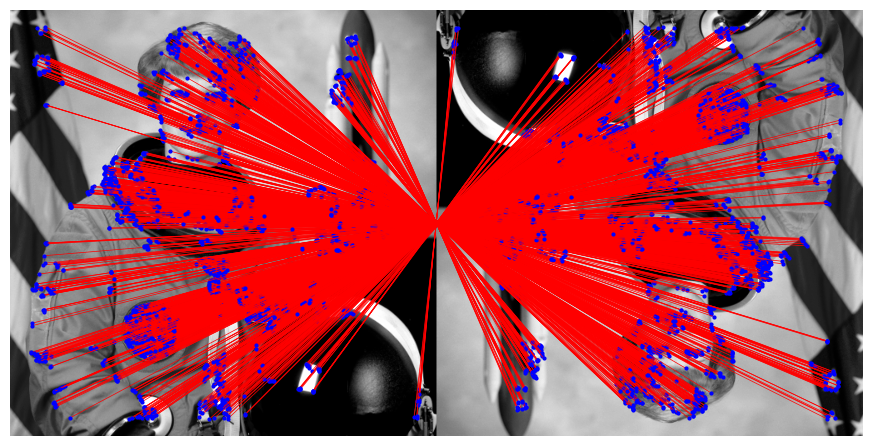

In [13]:
# --- ORB (Extended Activity) ---
from skimage.feature import ORB
orb = ORB(n_keypoints=3000, fast_threshold=0.07)
orb.detect_and_extract(img)
keypoints_orb = orb.keypoints
descriptors_orb = orb.descriptors
orb1 = ORB(n_keypoints=3000, fast_threshold=0.07)
orb1.detect_and_extract(img_transform)
keypoints1_orb = orb1.keypoints
descriptors1_orb = orb1.descriptors
matches_orb = match_descriptors(descriptors_orb, descriptors1_orb, max_ratio = 0.6, cross_check=True)
fig, ax = plt.subplots(nrows=1,ncols=1,figsize = (11,8))
custom_plot_matches(ax, img, img_transform, keypoints_orb, keypoints1_orb, matches_orb)
